# Comparación de Algoritmos No Supervisados
## Dataset: Hotel Bookings

Este notebook compara todos los algoritmos no supervisados implementados en `pckEDA`:

| Algoritmo | Tipo | Objetivo |
|-----------|------|----------|
| ACP | Reducción dimensional | Varianza máxima (lineal) |
| t-SNE | Reducción dimensional | Estructura local (no lineal) |
| UMAP | Reducción dimensional | Estructura local y global |
| K-Means | Clustering | Grupos compactos, esféricos |
| HAC | Clustering | Jerarquía de grupos |

### Estructura del análisis
1. Preparación de datos (una sola vez)
2. Comparación de proyecciones dimensionales (ACP vs t-SNE vs UMAP)
3. Comparación de clustering (K-Means vs HAC)
4. Visualización cruzada: proyecciones coloreadas por clusters

## 1. Importación de librerías

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
import pckEDA as mf

%matplotlib inline

RUTA = '../datasets/hotel_bookings.csv'
print('pckEDA cargado. Algoritmos disponibles: ACP, HAC, KMeans, TSNE, UMAP')

pckEDA cargado. Algoritmos disponibles: ACP, HAC, KMeans, TSNE, UMAP


## 2. Función de preprocesamiento compartida

Todos los modelos reciben el mismo dataset con idéntico preprocesamiento.
Encapsulamos los pasos en una función para evitar repetición.

In [2]:
def preparar(modelo):
    """Aplica el preprocesamiento estándar del dataset hotel_bookings al modelo dado."""
    modelo.codificarCategorica('hotel')
    modelo.codificarCategorica('arrival_date_month')
    modelo.codificarCategorica('assigned_room_type')
    modelo.codificarCategorica('deposit_type', mapeo={'No Deposit': 0, 'Non Refund': 1, 'Refundable': 2})
    modelo.codificarCategorica('customer_type')
    modelo.codificarCategorica('reservation_status')
    modelo.eliminarDuplicados()
    modelo.eliminarNulos()
    modelo.analisisNumerico()
    return modelo

## 3. Ajuste de todos los modelos

In [3]:
# Reducción dimensional
acp  = preparar(mf.ACP(pd.read_csv(RUTA, index_col=0).pipe(lambda df: df.assign(
    **{c: df[c].map({v: i for i, v in enumerate(sorted(df[c].dropna().unique()))})
       for c in ['hotel','arrival_date_month','assigned_room_type','customer_type','reservation_status']},
    deposit_type=df['deposit_type'].map({'No Deposit': 0, 'Non Refund': 1, 'Refundable': 2})
)).dropna().select_dtypes(include='number'), n_componentes=5))

tsne = preparar(mf.TSNE(RUTA, 1, n_componentes=2, perplejidad=30))
tsne.ajustar()
print('t-SNE ajustado ✓')

umap = preparar(mf.UMAP(RUTA, 1, n_componentes=2, n_vecinos=15))
umap.ajustar()
print('UMAP ajustado ✓')

# Clustering
km  = preparar(mf.KMeans(RUTA, 1, n_clusters=4))
km.ajustar()
print('K-Means ajustado ✓')

hac = preparar(mf.HAC(RUTA, 1, n_clusters=4, metodo='ward'))
hac.ajustar()
print('HAC ajustado ✓')

Columna 'hotel' codificada con el mapeo:
  0 → 0
  1 → 1
Columna 'arrival_date_month' codificada con el mapeo:
  0 → 0
  1 → 1
  2 → 2
  3 → 3
  4 → 4
  5 → 5
  6 → 6
  7 → 7
Columna 'assigned_room_type' codificada con el mapeo:
  0 → 0
  1 → 1
  2 → 2
  3 → 3
  4 → 4
  5 → 5
  6 → 6
  7 → 7
  8 → 8
  9 → 9
Columna 'deposit_type' codificada con el mapeo:
  No Deposit → 0
  Non Refund → 1
  Refundable → 2
Columna 'customer_type' codificada con el mapeo:
  0 → 0
  1 → 1
  2 → 2
  3 → 3
Columna 'reservation_status' codificada con el mapeo:
  0 → 0
  1 → 1
  2 → 2
Se eliminaron 13 filas duplicadas. Total actual: 395 filas.
Valores nulos antes: 395 en 395 filas.
hotel                          0
is_canceled                    0
lead_time                      0
arrival_date_month             0
stays_in_weekend_nights        0
                              ..
customer_type                  0
adr                            0
required_car_parking_spaces    0
total_of_special_requests      0
rese

> **Nota sobre ACP:** como `ACP` recibe un DataFrame (no path/num), el preprocesamiento
> se aplica manualmente en la celda anterior. Los demás modelos usan la función `preparar()`.

## 4. Comparación de proyecciones dimensionales

### 4.1 Proyecciones sin etiquetas

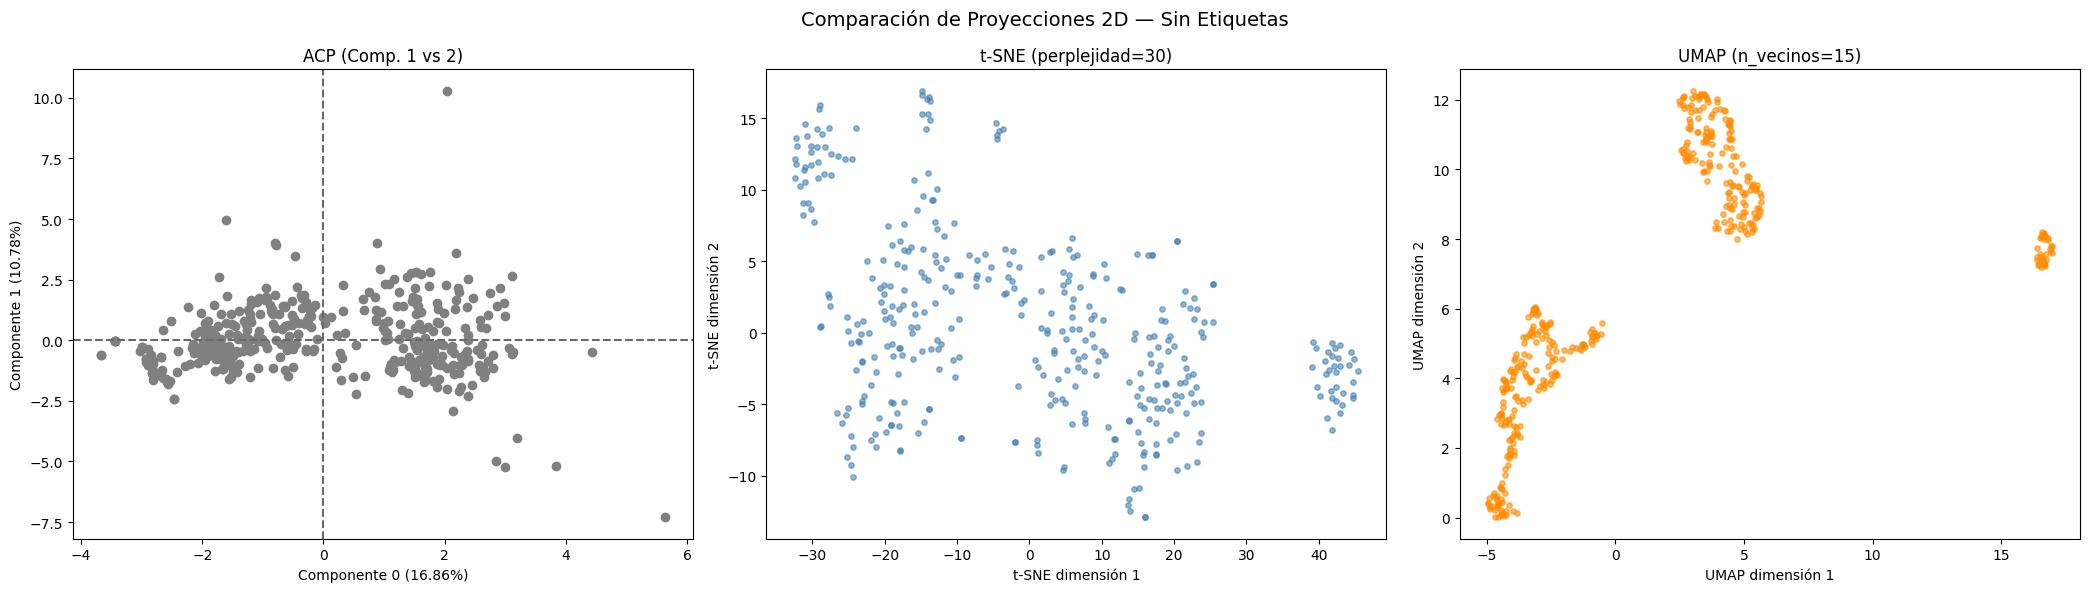

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Comparación de Proyecciones 2D — Sin Etiquetas', fontsize=14)

# ACP
plt.sca(axes[0])
acp.plot_plano_principal(ejes=[0, 1], ind_labels=False, titulo='ACP (Comp. 1 vs 2)')

# t-SNE
plt.sca(axes[1])
tsne.plot_proyeccion(titulo='t-SNE (perplejidad=30)')

# UMAP
plt.sca(axes[2])
umap.plot_proyeccion(titulo='UMAP (n_vecinos=15)')

plt.tight_layout()
plt.show()

### 4.2 Proyecciones coloreadas por K-Means

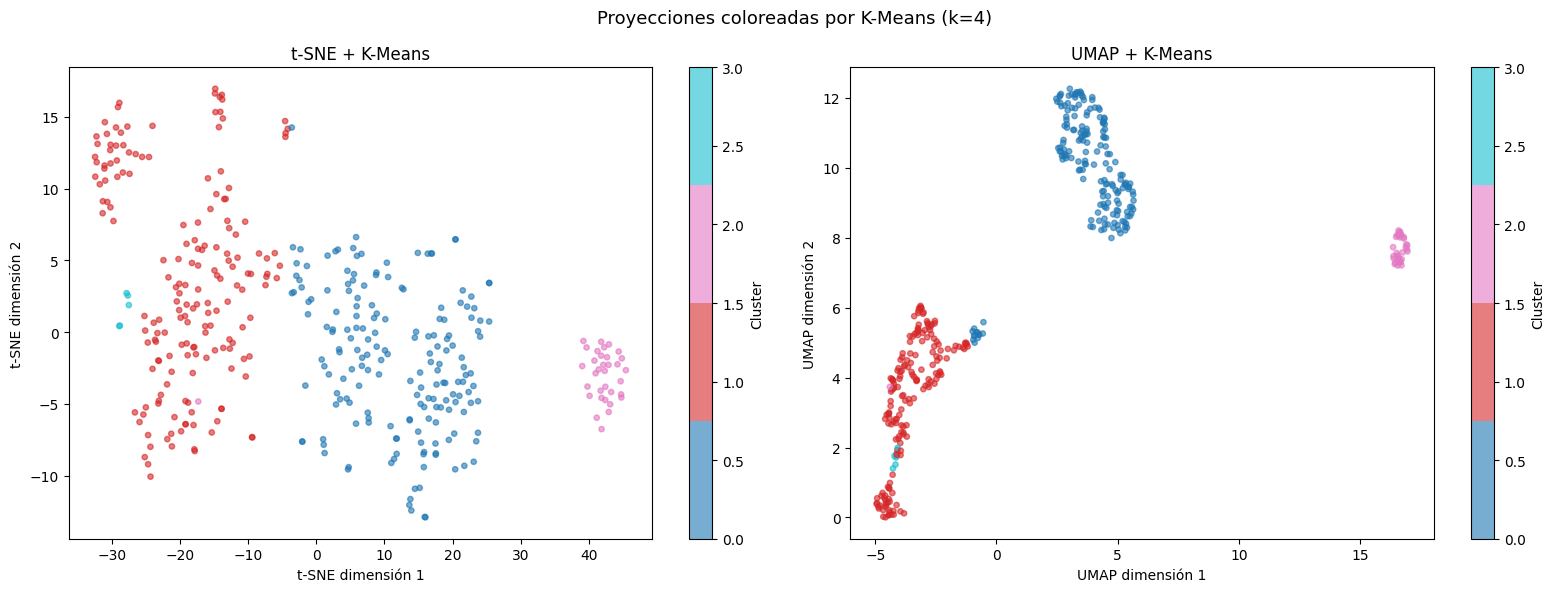

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Proyecciones coloreadas por K-Means (k=4)', fontsize=13)

plt.sca(axes[0])
tsne.plot_proyeccion(etiquetas=km.etiquetas, titulo='t-SNE + K-Means')

plt.sca(axes[1])
umap.plot_proyeccion(etiquetas=km.etiquetas, titulo='UMAP + K-Means')

plt.tight_layout()
plt.show()

### 4.3 Proyecciones coloreadas por HAC

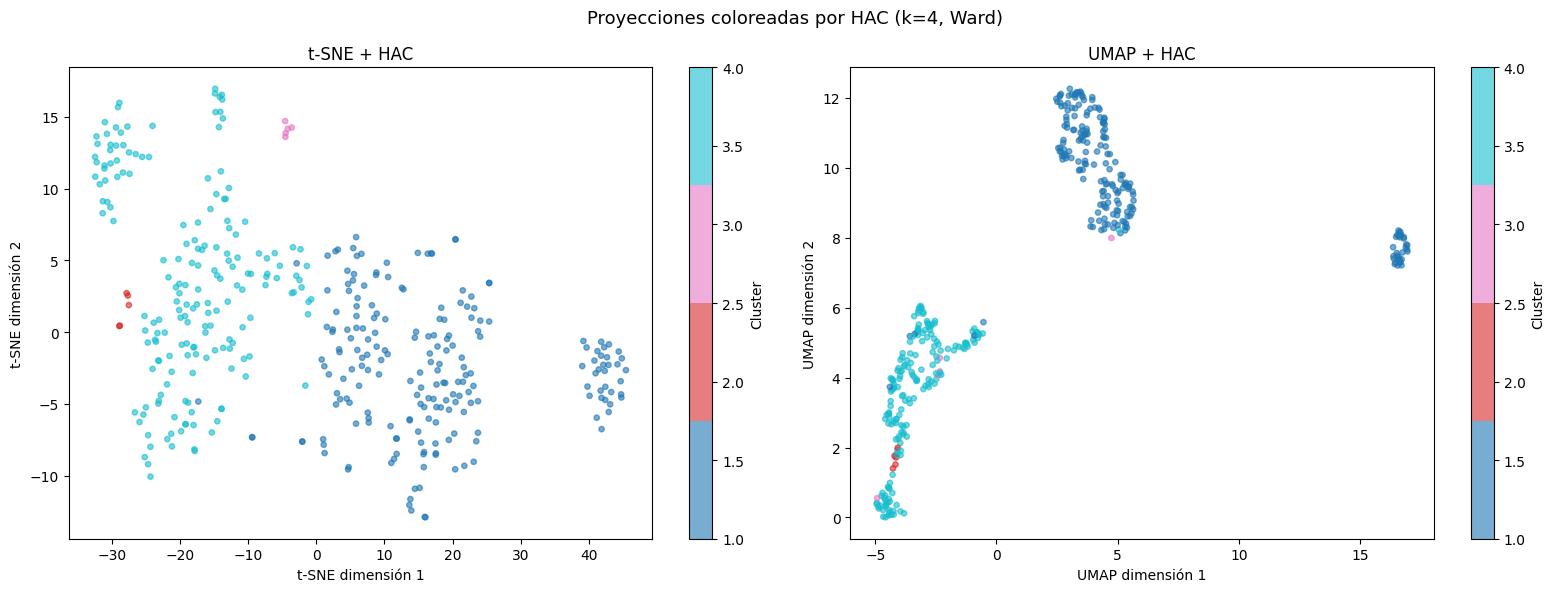

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Proyecciones coloreadas por HAC (k=4, Ward)', fontsize=13)

plt.sca(axes[0])
tsne.plot_proyeccion(etiquetas=hac.etiquetas, titulo='t-SNE + HAC')

plt.sca(axes[1])
umap.plot_proyeccion(etiquetas=hac.etiquetas, titulo='UMAP + HAC')

plt.tight_layout()
plt.show()

## 5. Comparación de clustering

### 5.1 Métricas comparativas

In [7]:
comparacion = pd.DataFrame({
    'Algoritmo'    : ['K-Means', 'HAC (Ward)'],
    'n_clusters'   : [km.n_clusters, hac.n_clusters],
    'Silhouette'   : [round(km.silhouette, 4), None],
    'Cofenética'   : [None, round(hac.cophenet_corr, 4)],
    'Inercia'      : [round(km.inercia, 2), None],
})
comparacion

,Algoritmo,n_clusters,Silhouette,Cofenética,Inercia
0,K-Means,4,0.1552,NaN,5834.15
1,HAC (Ward),4,NaN,0.3613,NaN


### 5.2 Distribución de clusters

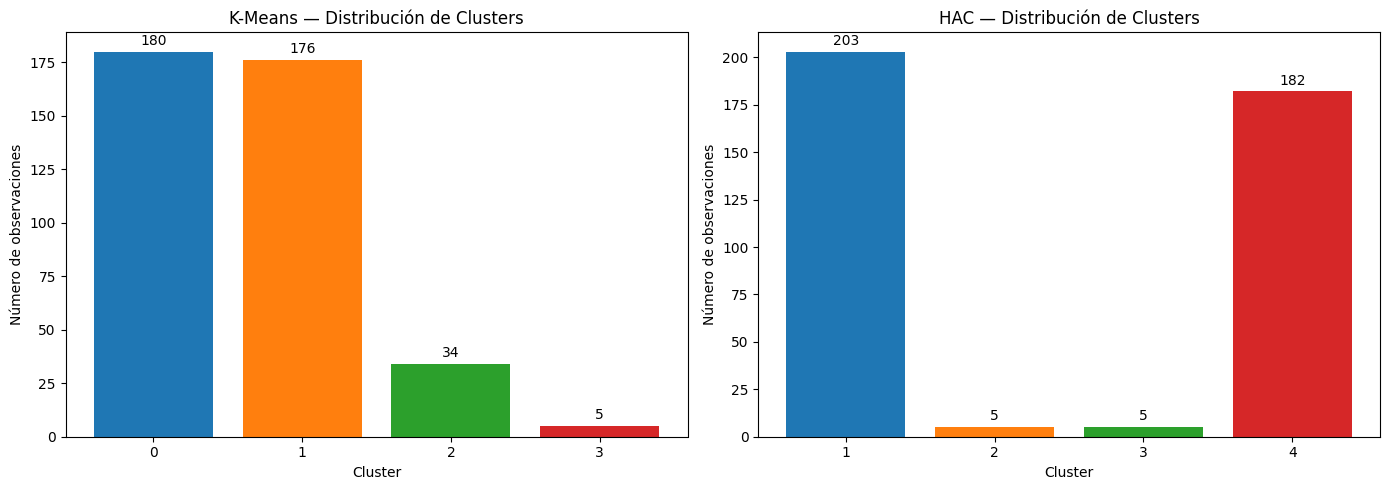

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
km.plot_distribucion(titulo='K-Means — Distribución de Clusters')

plt.sca(axes[1])
hac.plot_distribucion(titulo='HAC — Distribución de Clusters')

plt.tight_layout()
plt.show()

### 5.3 Perfiles de clusters

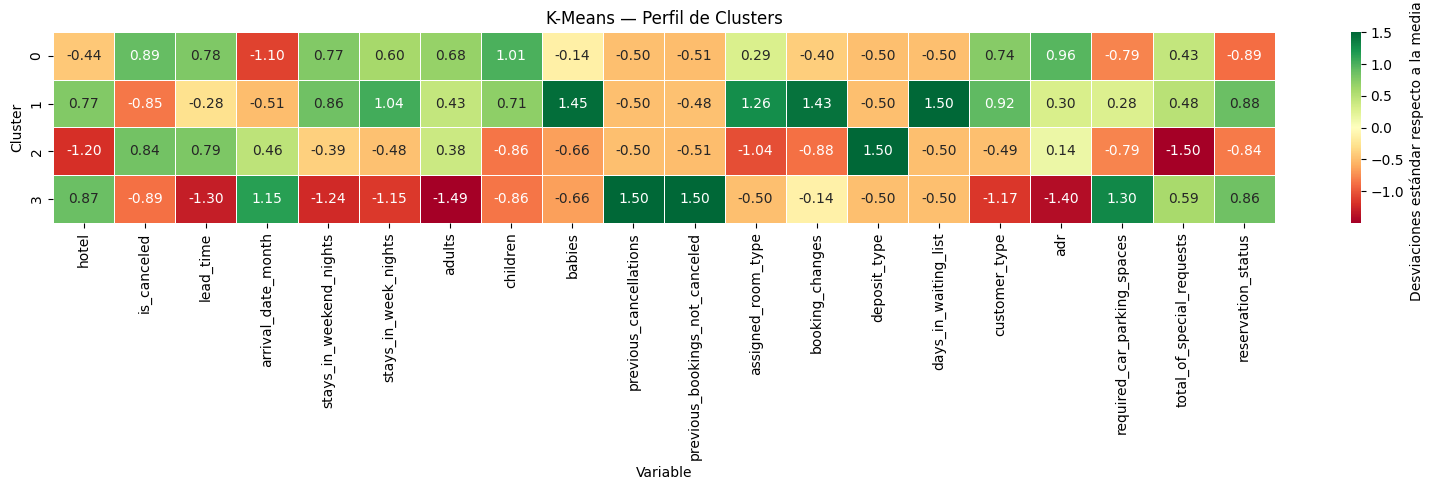

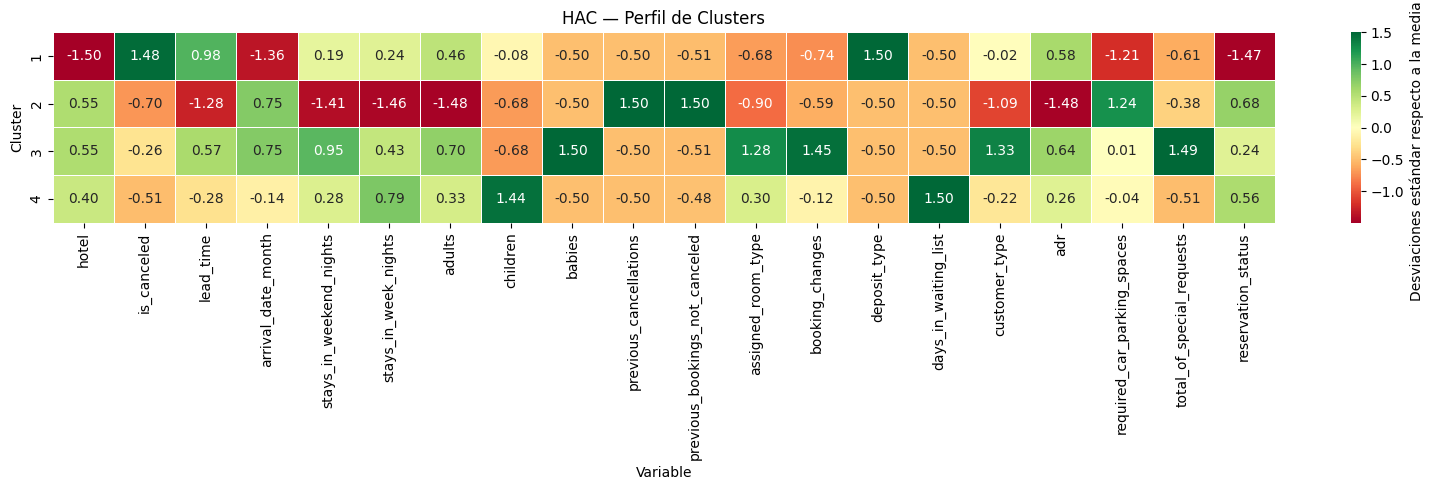

In [9]:
plt.figure(figsize=(16, 5))
km.plot_mapa_calor(titulo='K-Means — Perfil de Clusters')
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 5))
hac.plot_mapa_calor(titulo='HAC — Perfil de Clusters')
plt.tight_layout()
plt.show()

### 5.4 Radar comparativo de clusters

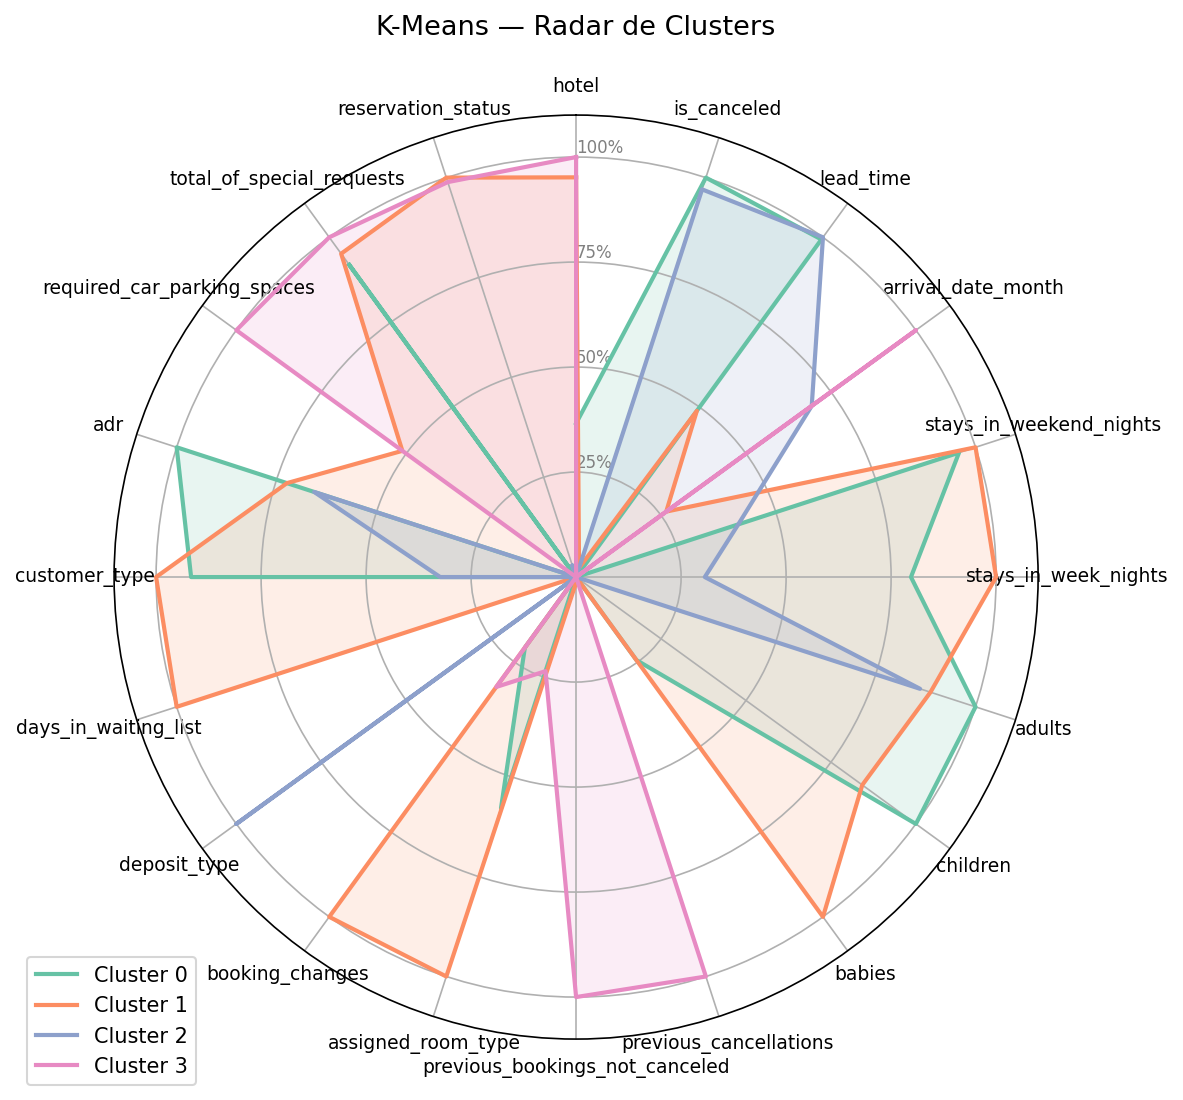

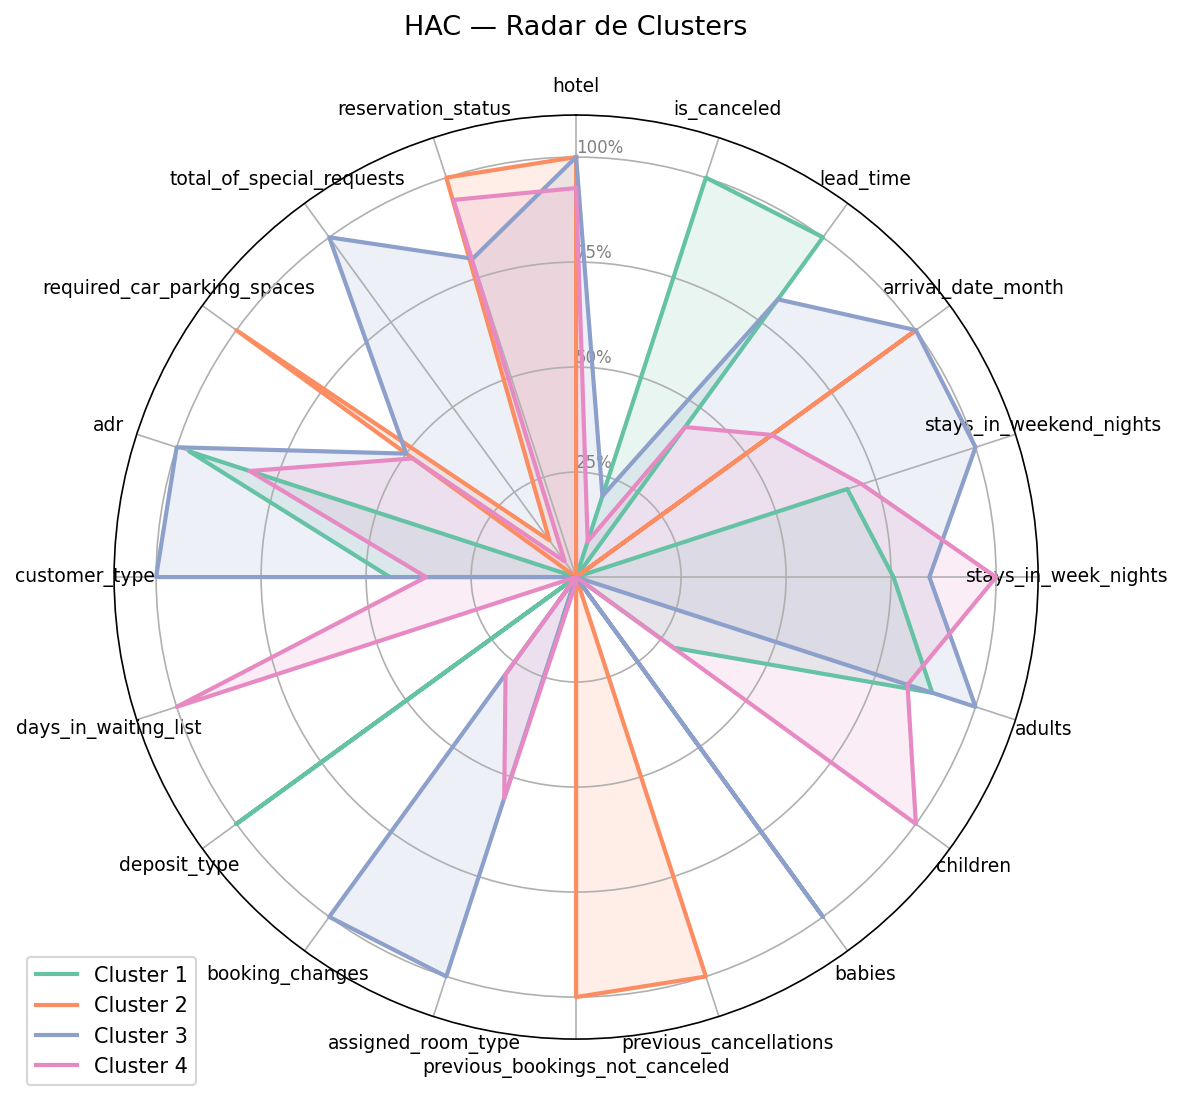

In [10]:
km.plot_radar(titulo='K-Means — Radar de Clusters')
plt.show()

hac.plot_radar(titulo='HAC — Radar de Clusters')
plt.show()

### 5.5 Barras de centroides

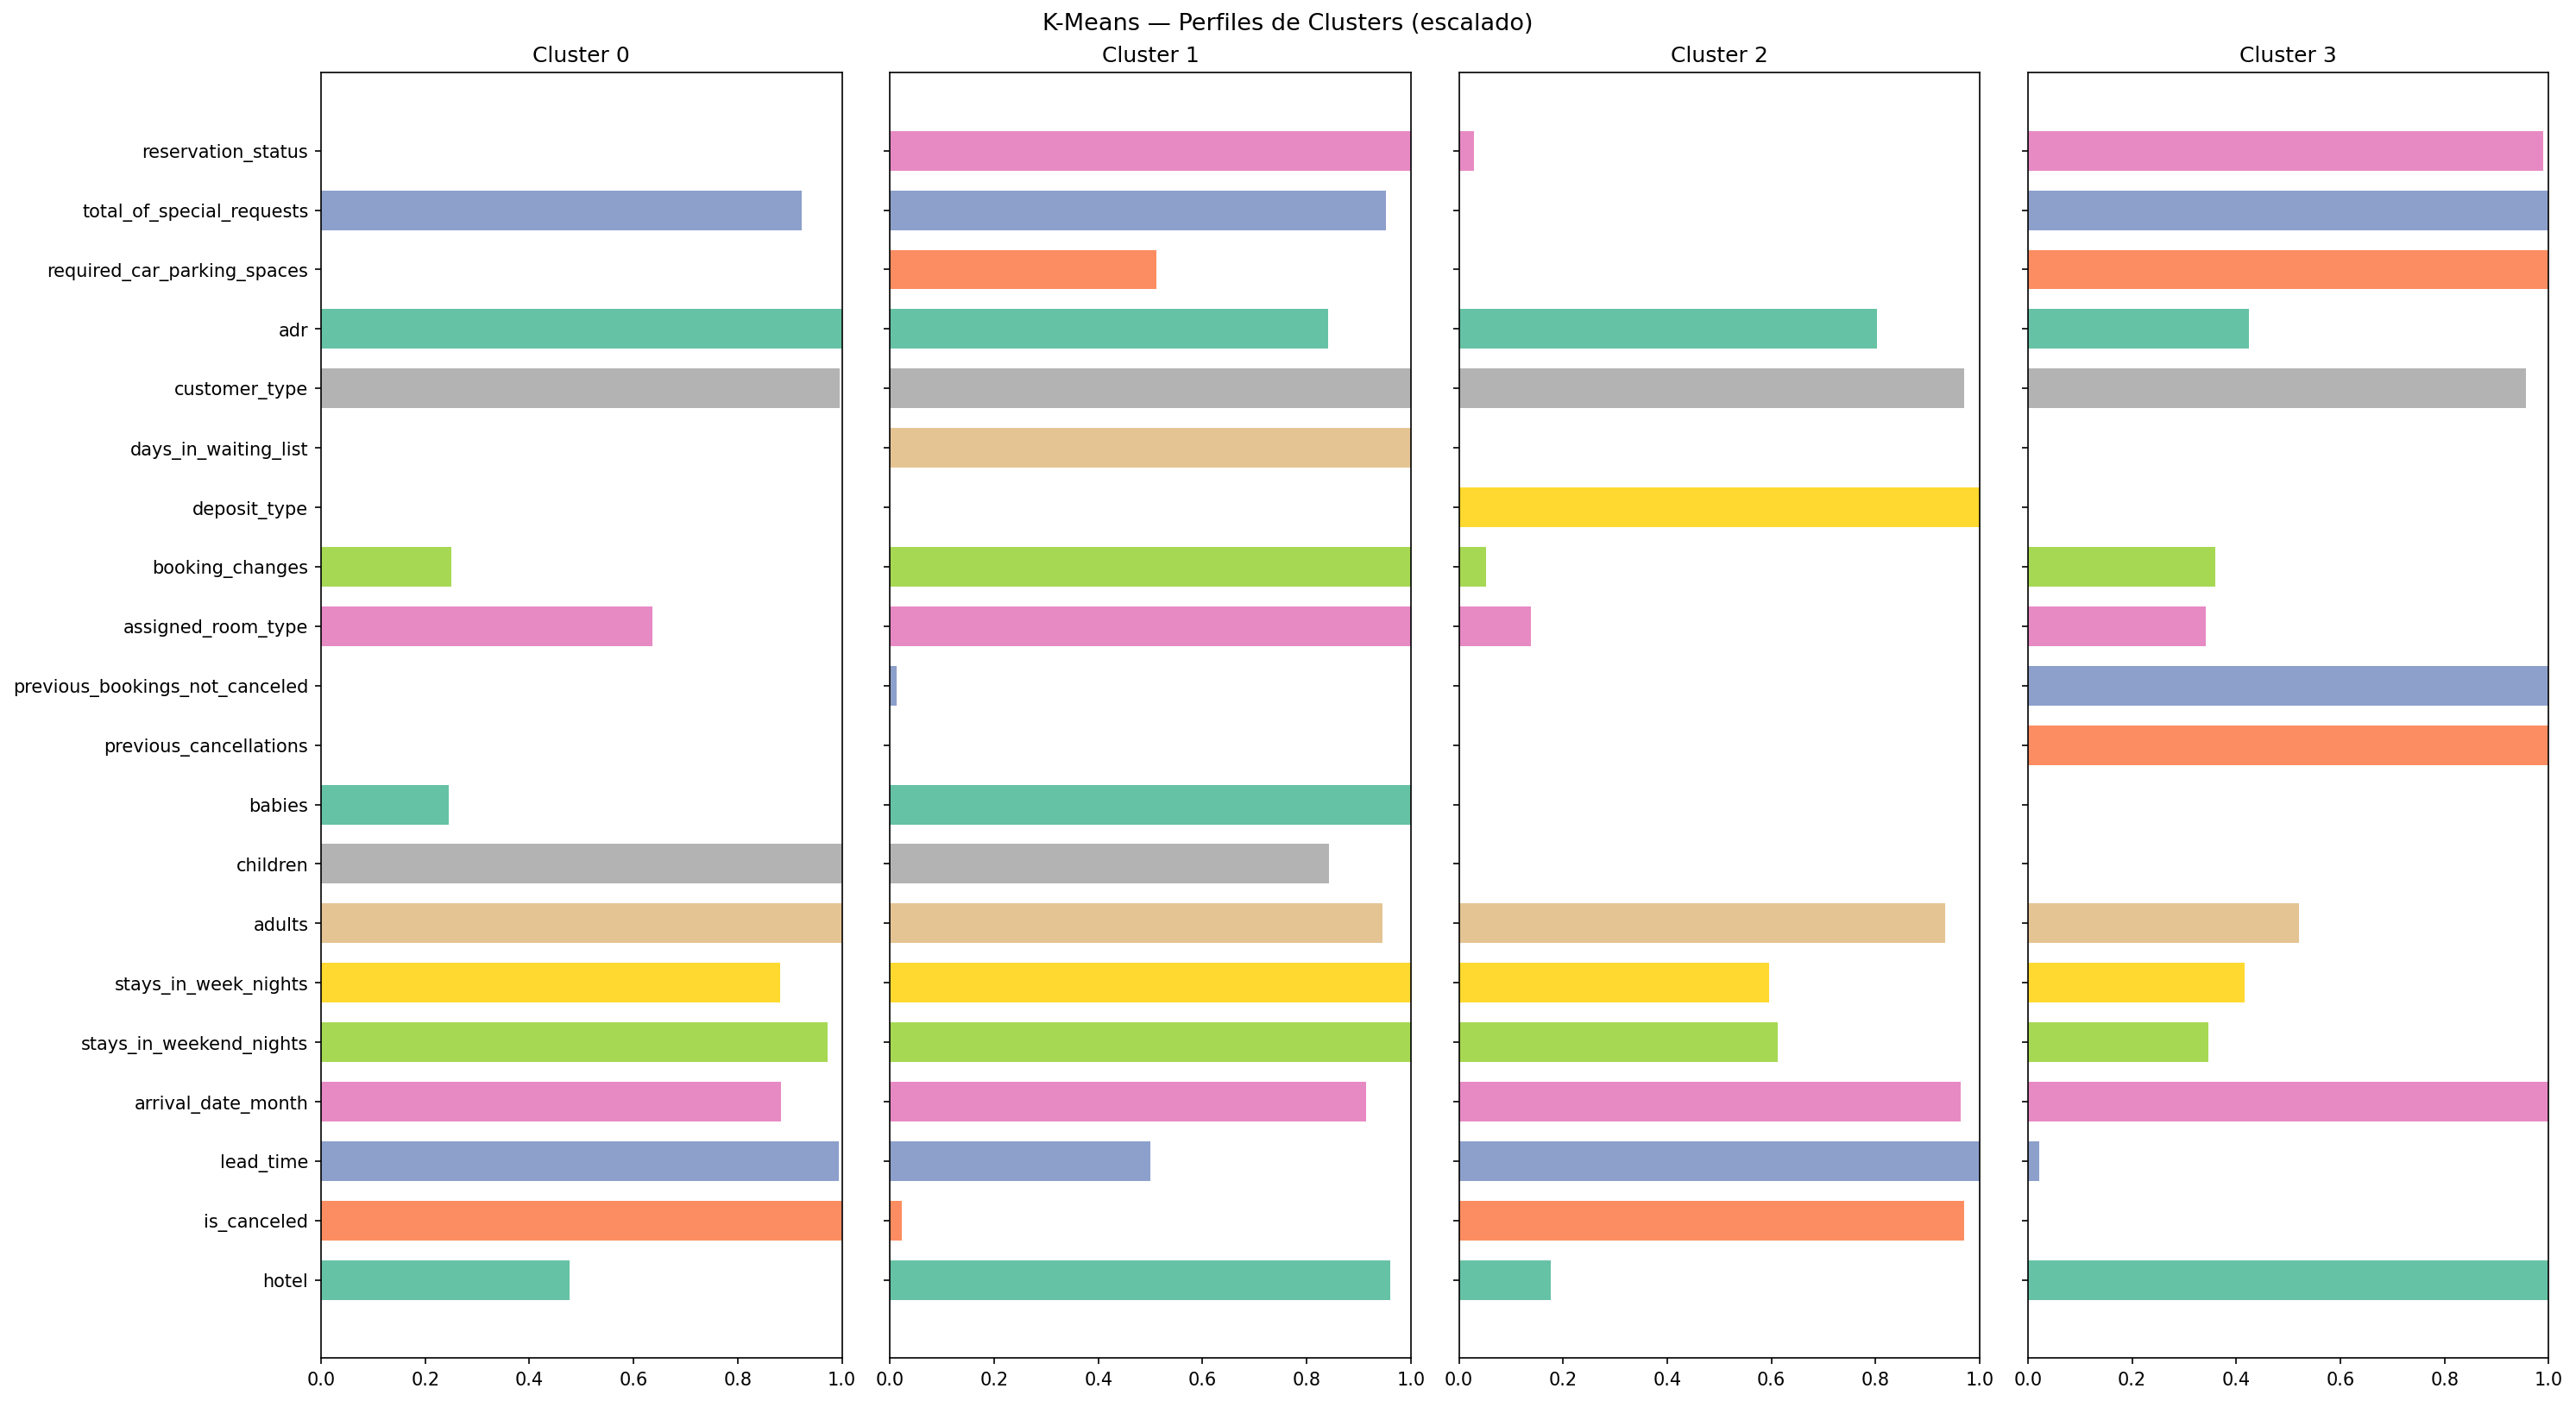

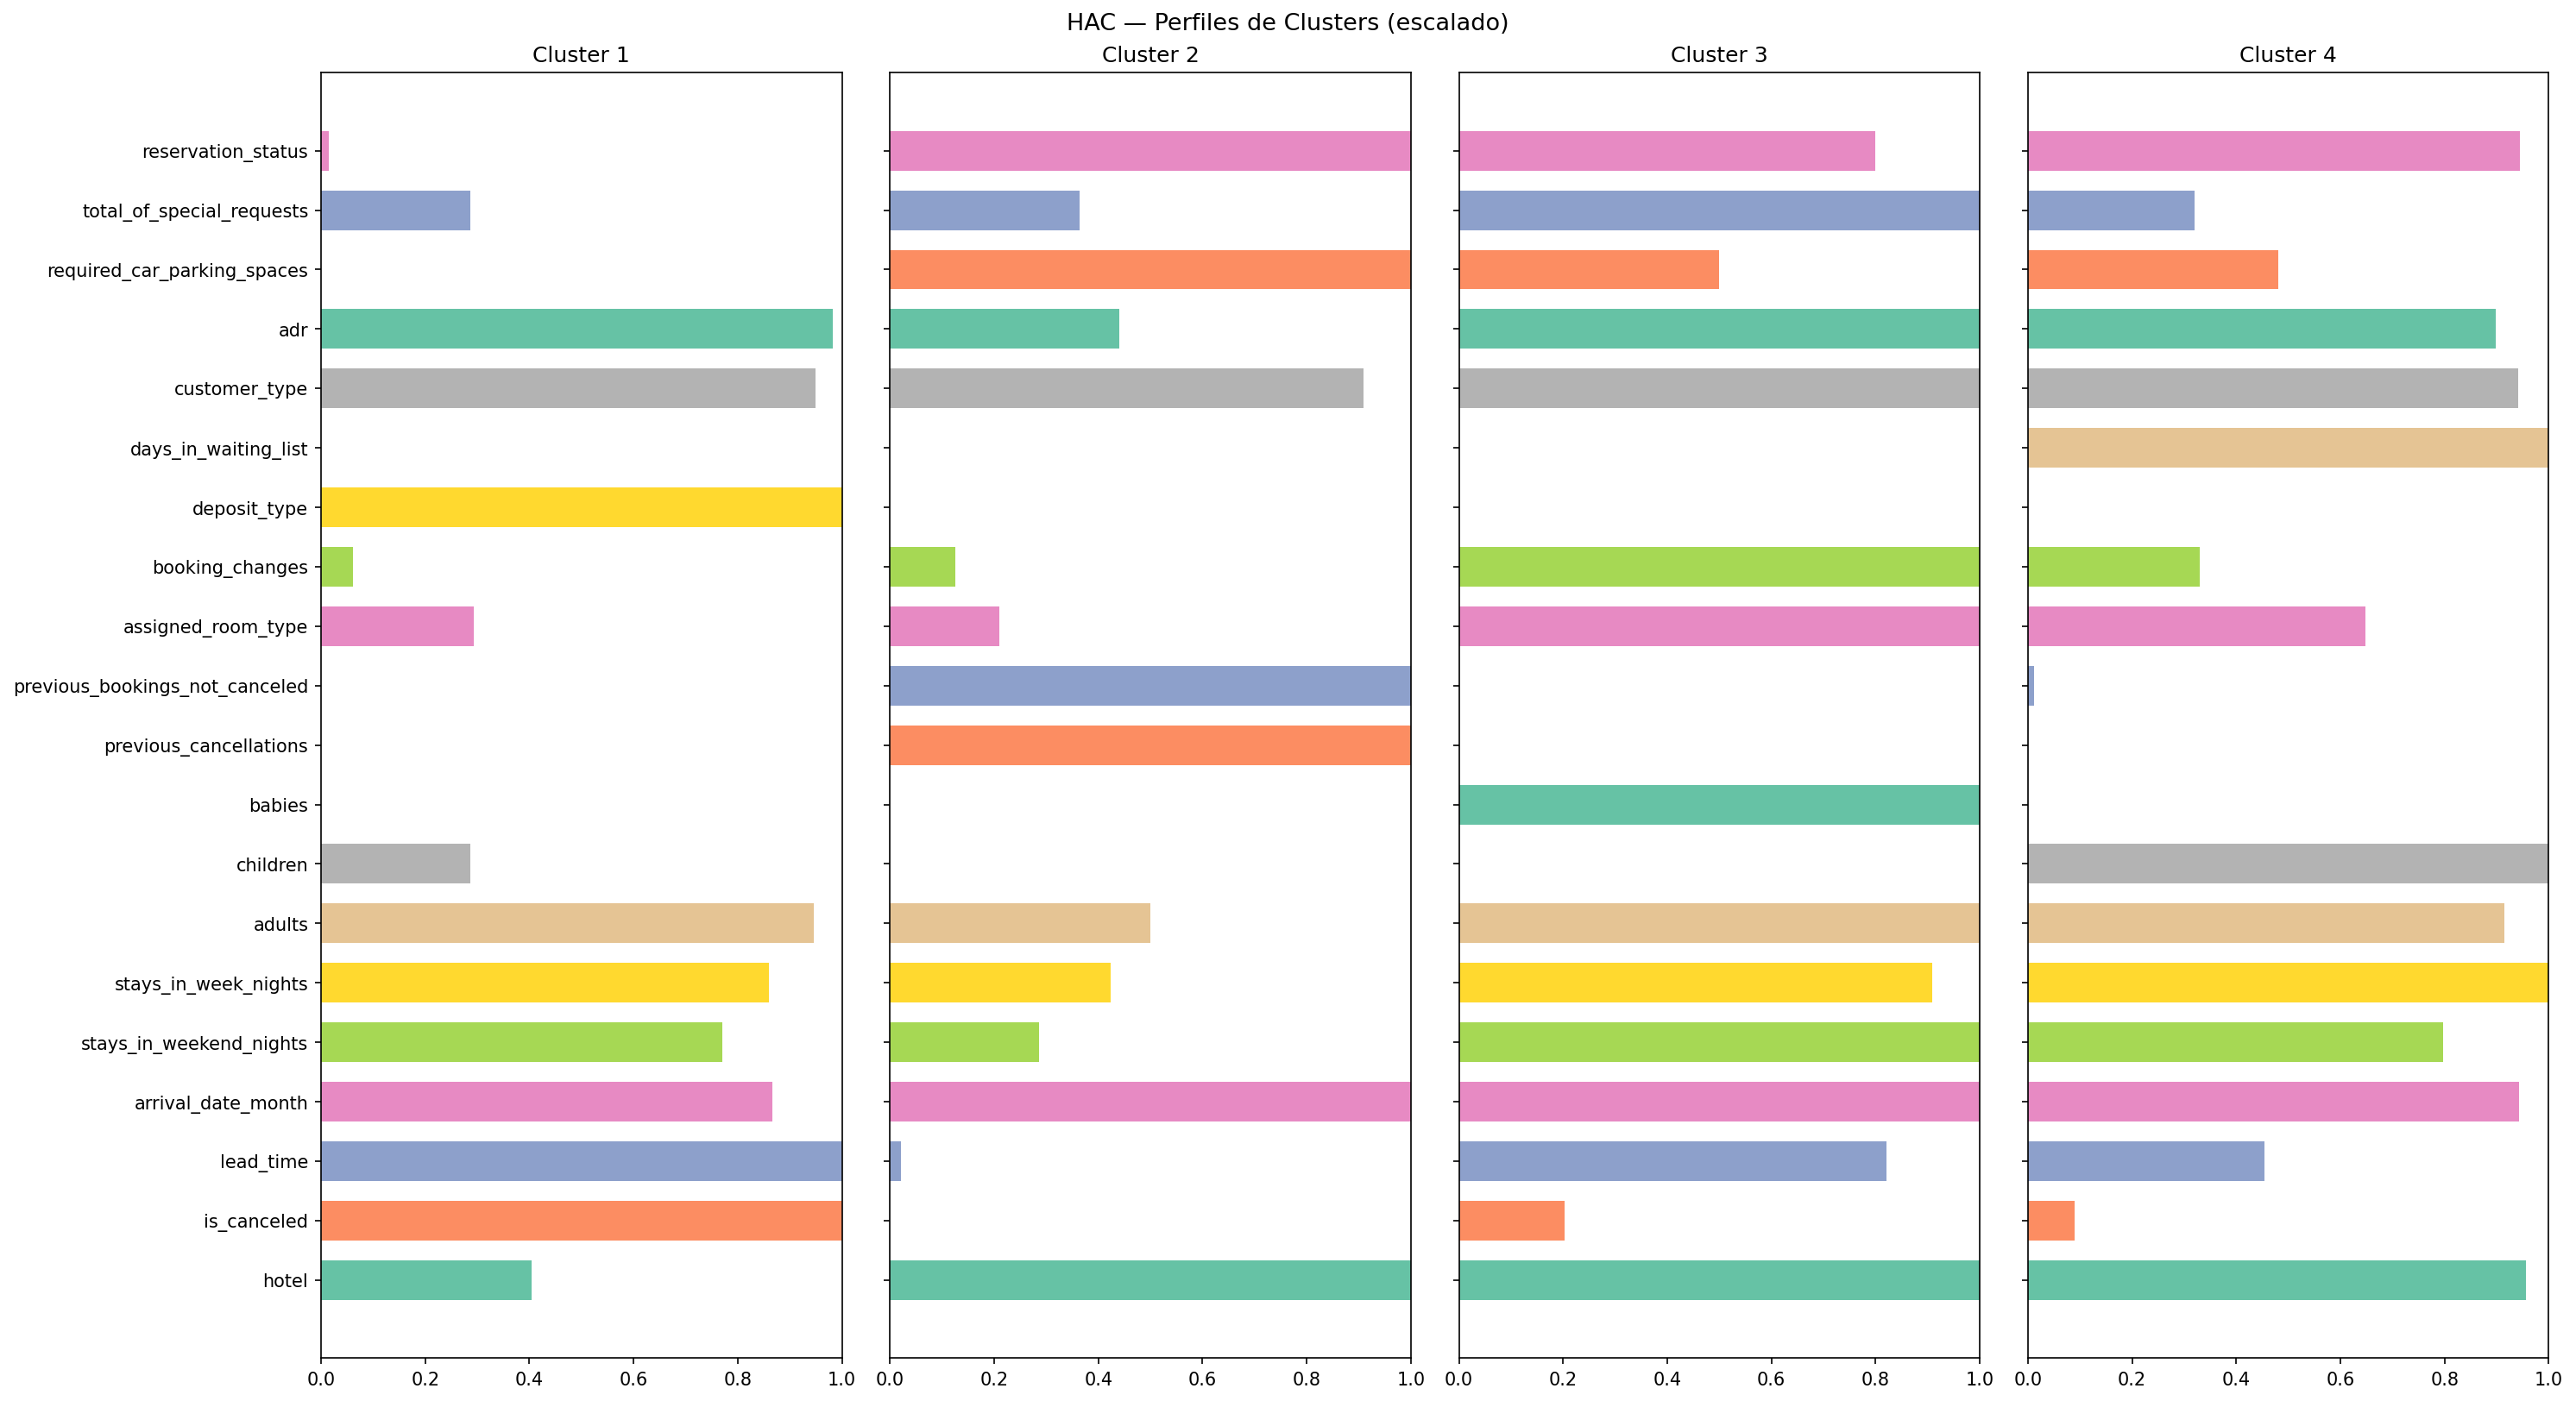

In [11]:
km.plot_barras(
    titulo='K-Means — Perfiles de Clusters (escalado)',
    escala=True
)
plt.show()

hac.plot_barras(
    titulo='HAC — Perfiles de Clusters (escalado)',
    escala=True
)
plt.show()

## 6. Resumen comparativo

### ¿Qué algoritmo elegir?

In [12]:
resumen = pd.DataFrame([
    {'Algoritmo': 'ACP',    'Tipo': 'Reducción', 'Lineal': 'Sí',  'Nuevos datos': 'Sí',  'Veloz en big data': 'Sí',  'Parámetro clave': 'n_componentes'},
    {'Algoritmo': 't-SNE',  'Tipo': 'Reducción', 'Lineal': 'No',  'Nuevos datos': 'No',  'Veloz en big data': 'No',  'Parámetro clave': 'perplejidad'},
    {'Algoritmo': 'UMAP',   'Tipo': 'Reducción', 'Lineal': 'No',  'Nuevos datos': 'Sí',  'Veloz en big data': 'Sí',  'Parámetro clave': 'n_vecinos'},
    {'Algoritmo': 'K-Means','Tipo': 'Clustering','Lineal': 'N/A', 'Nuevos datos': 'Sí',  'Veloz en big data': 'Sí',  'Parámetro clave': 'n_clusters'},
    {'Algoritmo': 'HAC',    'Tipo': 'Clustering','Lineal': 'N/A', 'Nuevos datos': 'No',  'Veloz en big data': 'No',  'Parámetro clave': 'metodo + n_clusters'},
])
resumen

,Algoritmo,Tipo,Lineal,Nuevos datos,Veloz en big data,Parámetro clave
0,ACP,Reducción,Sí,Sí,Sí,n_componentes
1,t-SNE,Reducción,No,No,No,perplejidad
2,UMAP,Reducción,No,Sí,Sí,n_vecinos
3,K-Means,Clustering,N/A,Sí,Sí,n_clusters
4,HAC,Clustering,N/A,No,No,metodo + n_clusters


## 7. Conclusiones

- **ACP** es el punto de partida: rápido, interpretable, ideal para entender qué variables explican la varianza.
- **t-SNE** revela estructuras no lineales que ACP no puede capturar, pero sus proyecciones no son reproducibles sin `random_state`.
- **UMAP** es la evolución de t-SNE: más rápido, más estable, y admite proyección de nuevos datos.
- **K-Means** es eficiente para datasets grandes, pero asume clusters esféricos y requiere definir `k` a priori.
- **HAC** es ideal cuando se desconoce el número de clusters — el dendrograma guía la decisión.
- La combinación más poderosa: usar **UMAP + K-Means o HAC** — el embedding revela la estructura, el clustering la formaliza.